In [3]:
import pandas as pd
from sqlalchemy import create_engine

username = "root"
password = ""
host = "127.0.0.1"
port = 3306
database = "salessight_db"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)
df = pd.read_sql("SELECT * FROM superstore_sales", engine)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,postal_code,city,...,discount,profit,year,month,month_name,quarter,shipping_days,profit_margin,is_loss,discount_band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.91,2016,11,November,4,3,0.1600,0,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.58,2016,11,November,4,3,0.3000,0,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.87,2016,6,June,2,4,0.4700,0,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.03,2015,10,October,4,7,-0.4000,1,Medium
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.52,2015,10,October,4,7,0.1125,0,Low


### Monthly Sales Trend

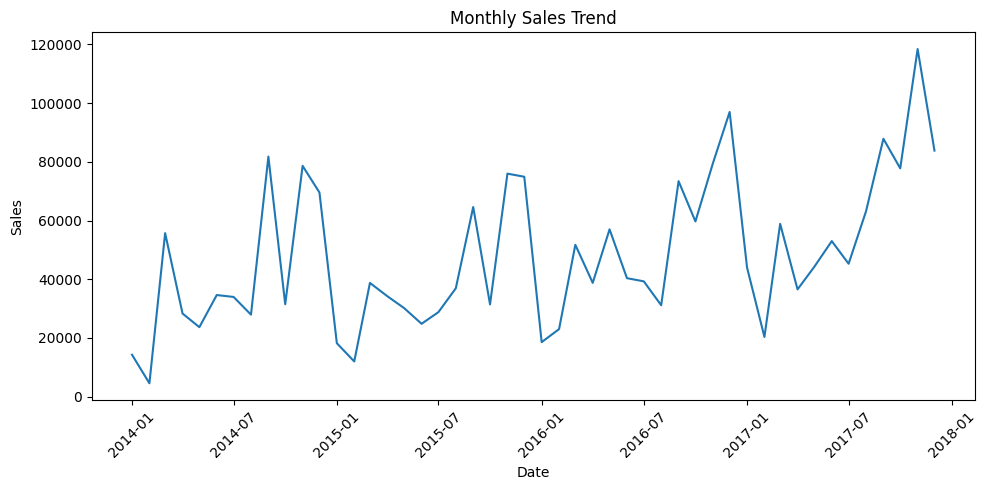

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

monthly_sales = df.groupby(["year", "month"])["sales"].sum().reset_index()

monthly_sales["date"] = pd.to_datetime(
    monthly_sales["year"].astype(str) + "-" + monthly_sales["month"].astype(str) + "-01"
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["date"], monthly_sales["sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Profit By Region

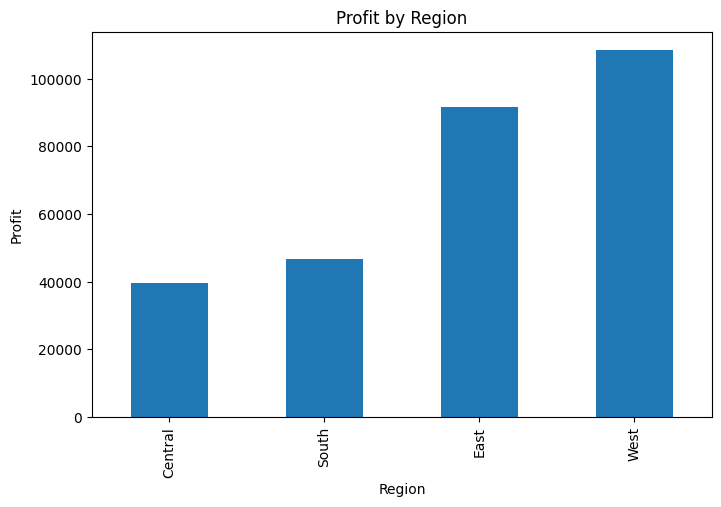

In [5]:
region_profit = df.groupby("region")["profit"].sum().sort_values()

plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

### Discount vs Profit

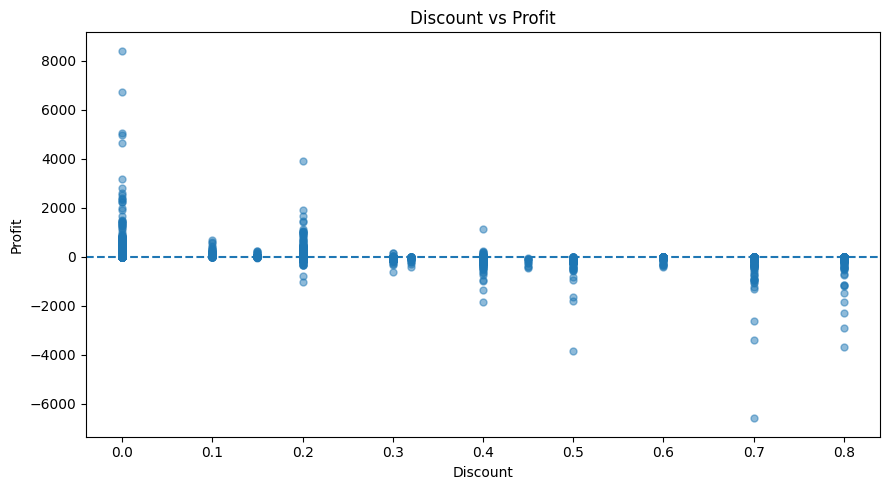

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(df["discount"], df["profit"], alpha=0.5, s=25)
plt.axhline(y=0, linestyle="--")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### Category Profit

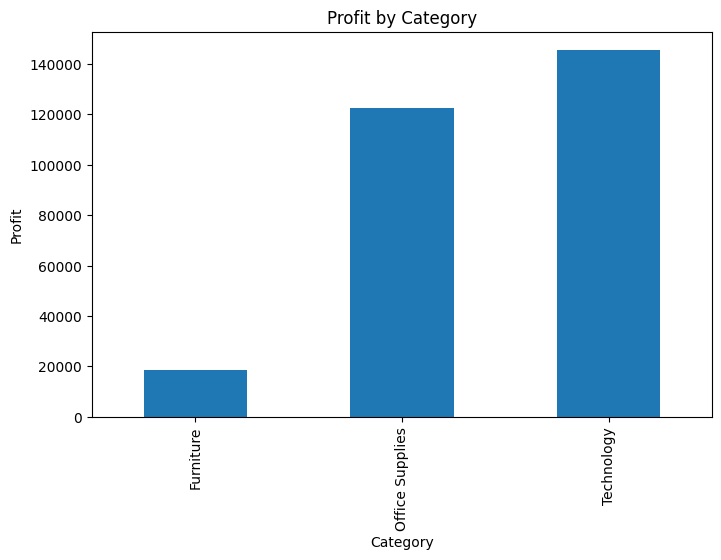

In [7]:
category_profit = df.groupby("category")["profit"].sum().sort_values()

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

### Shipping days by Ship Mode

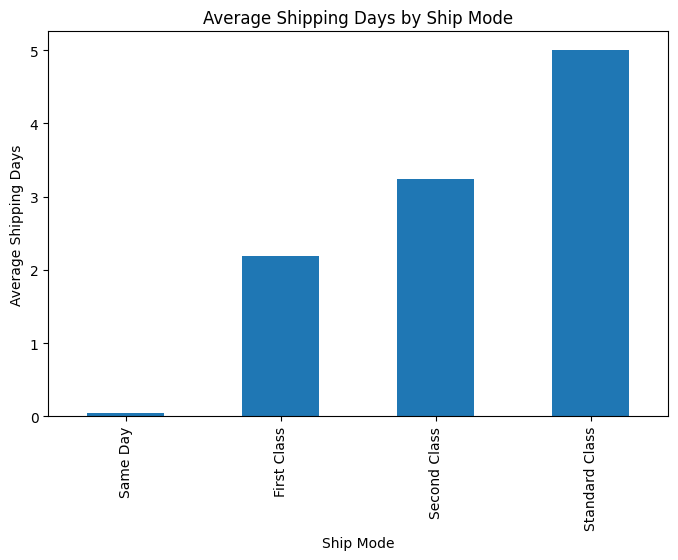

In [8]:
ship_mode_days = df.groupby("ship_mode")["shipping_days"].mean().sort_values()

plt.figure(figsize=(8,5))
ship_mode_days.plot(kind="bar")
plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")
plt.show()

### Make Monthly Forecast Data

In [9]:
monthly_sales = df.groupby(["year", "month"])["sales"].sum().reset_index()
monthly_sales = monthly_sales.sort_values(["year", "month"]).reset_index(drop=True)

monthly_sales["date"] = pd.to_datetime(
    monthly_sales["year"].astype(str) + "-" + monthly_sales["month"].astype(str) + "-01"
)

monthly_sales["time_index"] = range(len(monthly_sales))

### Train Simple Regression Model

In [10]:
from sklearn.linear_model import LinearRegression

X = monthly_sales[["time_index"]]
y = monthly_sales["sales"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predit Next 12 months

In [15]:
future = pd.DataFrame({
    "time_index": range(len(monthly_sales), len(monthly_sales) + 12)
})

last_date = monthly_sales["date"].max()

future["date"] = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq="MS")

future["predicted_sales"] = model.predict(future[["time_index"]])

future

,time_index,date,predicted_sales
0,48,2018-01-01,69957.538910
1,49,2018-02-01,70859.546391
2,50,2018-03-01,71761.553872
3,51,2018-04-01,72663.561353
4,52,2018-05-01,73565.568834
5,53,2018-06-01,74467.576315
6,54,2018-07-01,75369.583796
7,55,2018-08-01,76271.591277
8,56,2018-09-01,77173.598758
9,57,2018-10-01,78075.606239


### Plot Forecast

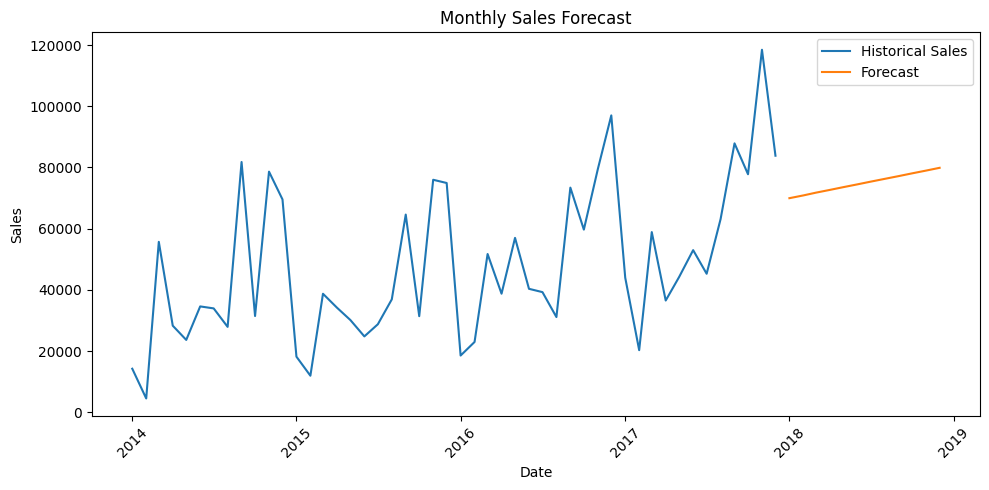

In [16]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["date"], monthly_sales["sales"], label="Historical Sales")
plt.plot(future["date"], future["predicted_sales"], label="Forecast")
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
future.to_csv("../outputs/superstore_forecast.csv", index=False)